In [51]:
import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import datasets

from model_loader import (
    make_model,
    DEVICE,
    ChannelSelectDataset,
)

import metrics

MODELS = [

    # --------------------------------------------------
    # SplitNetInterp
    # --------------------------------------------------
# border, splitnetinterp, tv 0.01
    {
        "name": "Interp Border D0",
        "path": "limited_prior_tests_interp/border_splitnet_interp_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
        "architecture": "splitnet_interp",
        "dataset_mode": "border",
    },

    {
        "name": "Interp Border D1",
        "path": "limited_prior_tests_interp/border_splitnet_interp_physics_limited_mask_mse_darcy_tvP_stats_d1p0_best_state.pt",
        "architecture": "splitnet_interp",
        "dataset_mode": "border",
    },

    {
        "name": "Interp Border D5",
        "path": "limited_prior_tests_interp/border_splitnet_interp_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
        "architecture": "splitnet_interp",
        "dataset_mode": "border",
    },

    {
        "name": "Interp Border D10",
        "path": "limited_prior_tests_interp/border_splitnet_interp_physics_limited_mask_mse_darcy_tvP_stats_d10p0_best_state.pt",
        "architecture": "splitnet_interp",
        "dataset_mode": "border",
    },

# border_sides, splitnetinterp, tv 0.01
    # {
    #     "name": "Interp BorderSides D0",
    #     "path": "limited_prior_tests_interp_nd_bs/border_sides_splitnet_interp_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
    #     "architecture": "splitnet_interp",
    #     "dataset_mode": "border_sides",
    # },

    # {
    #     "name": "Interp BorderSides D5",
    #     "path": "limited_prior_tests_interp_nd_bs/border_sides_splitnet_interp_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
    #     "architecture": "splitnet_interp",
    #     "dataset_mode": "border_sides",
    # },

    # --------------------------------------------------
    # SplitNet (older TV experiments)
    # --------------------------------------------------
# border, splitnet, tv 0.01 d0
    {
        "name": "SplitNet Border D0",
        "path": "limited_prior_tests2/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d0_best_state.pt",
        "architecture": "splitnet",
        "dataset_mode": "border",
    },
# border, splitnet, tv 0.01, d5
    {
        "name": "SplitNet Border D5",
        "path": "limited_prior_tests2/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_best_state.pt",
        "architecture": "splitnet",
        "dataset_mode": "border",
    },

    # --------------------------------------------------
    # tests33
    # --------------------------------------------------

    # border, splitnet
    {
        "name": "SplitNet Border D0 Tests33",
        "path": "tests33/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
        "architecture": "splitnet",
        "dataset_mode": "border",
    },
    {
        "name": "SplitNet Border D5 Tests33",
        "path": "tests33/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
        "architecture": "splitnet",
        "dataset_mode": "border",
    },

    # {
    #     "name": "SplitNet BorderSides D0 Tests33",
    #     "path": "tests33/border_sides_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
    #     "architecture": "splitnet",
    #     "dataset_mode": "border_sides",
    # },

    # {
    #     "name": "SplitNet BorderSides D5 Tests33",
    #     "path": "tests33/border_sides_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
    #     "architecture": "splitnet",
    #     "dataset_mode": "border_sides",
    # },

    # --------------------------------------------------
    # tests34
    # --------------------------------------------------

# border_sides, splitnet, tv 0.01

    # {
    #     "name": "SplitNet BorderSides D0 Tests34",
    #     "path": "tests34/border_sides_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
    #     "architecture": "splitnet",
    #     "dataset_mode": "border_sides",
    # },

    # {
    #     "name": "SplitNet BorderSides D5 Tests34",
    #     "path": "tests34/border_sides_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
    #     "architecture": "splitnet",
    #     "dataset_mode": "border_sides",
    # },

    # --------------------------------------------------
    # tests35
    # --------------------------------------------------
# border_sides, splitnet, tv 0.01, lr 2e-1
#     {
#         "name": "SplitNet BorderSides D0 LR2e-4",
#         "path": "tests35/border_sides_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
#         "architecture": "splitnet",
#         "dataset_mode": "border_sides",
#     },

#     {
#         "name": "SplitNet BorderSides D5 LR2e-4",
#         "path": "tests35/border_sides_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
#         "architecture": "splitnet",
#         "dataset_mode": "border_sides",
#     },
# # border, splitnet, tv 0.01, lr 2e-1
#     {
#         "name": "SplitNet Border D0 LR2e-4",
#         "path": "tests35/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d0p0_best_state.pt",
#         "architecture": "splitnet",
#         "dataset_mode": "border",
#     },

    # {
    #     "name": "SplitNet Border D5 LR2e-4",
    #     "path": "tests35/border_splitnet_physics_limited_mask_mse_darcy_tvP_stats_d5p0_best_state.pt",
    #     "architecture": "splitnet",
    #     "dataset_mode": "border",
    # },

]

for m in MODELS:
    if not os.path.exists(m["path"]):
        print("MISSING:", m["path"])

In [52]:
VAL_SIMS = np.load("../val_sims.npy")

VAL_SIMS = VAL_SIMS[VAL_SIMS < 500]

print(
    VAL_SIMS.min(),
    VAL_SIMS.max(),
    len(VAL_SIMS)
)

def load_model(info):

    model = make_model(
        model_type=info["architecture"],
        channels="KP",
    )

    model.load_state_dict(
        torch.load(
            info["path"],
            map_location=DEVICE,
        )
    )

    model.eval()

    return model

2 496 75


In [53]:
def evaluate_prediction(pred, label, mask):

    results = {}

    results["total_mse"] = (
        metrics.compute_metric(
            "mse",
            pred,
            label,
        ).item()
    )

    results["mask_mse"] = (
        metrics.compute_metric(
            "mse",
            pred,
            label,
            mask=mask,
            region="mask",
        ).item()
    )

    results["nonmask_mse"] = (
        metrics.compute_metric(
            "mse",
            pred,
            label,
            mask=mask,
            region="nonmask",
        ).item()
    )

    results["k_mse"] = (
        metrics.compute_metric(
            "mse",
            pred,
            label,
            channel=0,
        ).item()
    )

    results["p_mse"] = (
        metrics.compute_metric(
            "mse",
            pred,
            label,
            channel=1,
        ).item()
    )

    results["darcy"] = (
        metrics.compute_metric(
            "darcy",
            pred,
        ).item()
    )

    results["darcy_match"] = (
        metrics.compute_metric(
            "darcy_match",
            pred,
            label,
        ).item()
    )

    results["tv_pressure"] = (
        metrics.compute_metric(
            "tv",
            pred,
            channel=1,
        ).item()
    )

    return results

def evaluate_model(model, dataset):

    totals = {}

    count = 0

    for idx in range(len(dataset)):

        feat, label, mask = dataset[idx]

        with torch.no_grad():

            pred = model(
                feat.unsqueeze(0).to(DEVICE)
            ).cpu()

        label = label.unsqueeze(0)
        mask = mask.unsqueeze(0)

        metrics_here = evaluate_prediction(
            pred,
            label,
            mask,
        )

        for k, v in metrics_here.items():

            totals[k] = totals.get(k, 0.0) + v

        count += 1

    for k in totals:
        totals[k] /= count

    return totals

CACHE_DIR = "comparison_cache"

os.makedirs(
    CACHE_DIR,
    exist_ok=True,
)

def make_dataset(dataset_mode, sims):

    if dataset_mode == "border":
        base_dataset = datasets.BorderDenseDatasetLimited(
            sims=sims,
            channels="KP"
        )

    # elif dataset_mode == "border_sides":
    #     base_dataset = datasets.BorderDenseDatasetLimitedSides(
    #         sims=sims,
    #         channels="KP"
    #     )

    else:
        raise ValueError(dataset_mode)

    return ChannelSelectDataset(
        base_dataset,
        channels="KP"
    )

In [54]:
all_results = []

for info in MODELS:

    cache_file = os.path.join(
        CACHE_DIR,
        info["name"].replace(" ", "_") + ".json"
    )

    if os.path.exists(cache_file):

        print("Loading cache:", info["name"])

        with open(cache_file) as f:
            result = json.load(f)

    else:

        print("Evaluating:", info["name"])

        dataset = make_dataset(
        info["dataset_mode"],
        VAL_SIMS
    )

        model = load_model(info)

        result = evaluate_model(
            model,
            dataset
        )

        with open(cache_file, "w") as f:
            json.dump(result, f, indent=2)

    result["model"] = info["name"]

    all_results.append(result)

Loading cache: Interp Border D0
Loading cache: Interp Border D1
Loading cache: Interp Border D5
Loading cache: Interp Border D10
Loading cache: SplitNet Border D0
Loading cache: SplitNet Border D5
Loading cache: SplitNet Border D0 Tests33
Loading cache: SplitNet Border D5 Tests33


In [55]:
df = pd.DataFrame(all_results)

df = df.set_index("model")

df

,total_mse,mask_mse,nonmask_mse,k_mse,p_mse,darcy,darcy_match,tv_pressure
model,,,,,,,,
Interp Border D0,0.301297,0.004000,0.345917,0.181142,0.421451,0.001471,0.000526,0.015610
Interp Border D1,0.227650,0.017004,0.259265,0.035519,0.419780,0.000507,0.000729,0.015838
Interp Border D5,0.287226,0.005093,0.329570,0.180755,0.393697,0.000088,0.001307,0.014677
Interp Border D10,0.303695,0.006492,0.348301,0.172684,0.434706,0.000046,0.001478,0.018081
SplitNet Border D0,0.252602,0.002593,0.290125,0.075280,0.429925,0.001455,0.000516,0.017500
SplitNet Border D5,0.248036,0.003550,0.284730,0.082623,0.413449,0.000111,0.001237,0.015815
SplitNet Border D0 Tests33,0.308355,0.002757,0.354221,0.542238,0.074473,0.006339,0.004578,0.121210
SplitNet Border D5 Tests33,0.300687,0.003800,0.345246,0.029326,0.572049,0.000092,0.001301,0.024136


In [56]:
df["rank_score"] = (
    df["total_mse"].rank()
    +
    df["nonmask_mse"].rank()
    +
    df["darcy_match"].rank()
)

df.sort_values(
    "rank_score"
)

,total_mse,mask_mse,nonmask_mse,k_mse,p_mse,darcy,darcy_match,tv_pressure,rank_score
model,,,,,,,,,
Interp Border D1,0.227650,0.017004,0.259265,0.035519,0.419780,0.000507,0.000729,0.015838,5.0
SplitNet Border D0,0.252602,0.002593,0.290125,0.075280,0.429925,0.001455,0.000516,0.017500,7.0
SplitNet Border D5,0.248036,0.003550,0.284730,0.082623,0.413449,0.000111,0.001237,0.015815,8.0
Interp Border D0,0.301297,0.004000,0.345917,0.181142,0.421451,0.001471,0.000526,0.015610,14.0
Interp Border D5,0.287226,0.005093,0.329570,0.180755,0.393697,0.000088,0.001307,0.014677,14.0
SplitNet Border D5 Tests33,0.300687,0.003800,0.345246,0.029326,0.572049,0.000092,0.001301,0.024136,15.0
Interp Border D10,0.303695,0.006492,0.348301,0.172684,0.434706,0.000046,0.001478,0.018081,21.0
SplitNet Border D0 Tests33,0.308355,0.002757,0.354221,0.542238,0.074473,0.006339,0.004578,0.121210,24.0


In [57]:
SIM_INDEX = 0
STEP_INDEX = 100

In [58]:
def get_item_for_sim_step(dataset_mode, sim_id, step):
    sims = np.array([sim_id])
    dataset = make_dataset(dataset_mode, sims)
    return dataset[step]

In [59]:
def plot_model_comparison(sim_id, step, channel=1):
    """
    channel=0 -> K
    channel=1 -> P
    """

    channel_name = "K" if channel == 0 else "P"

    n_models = len(MODELS)

    plt.figure(figsize=(4 * (n_models + 2), 4))

    # Use the first model's dataset just to show one reference input/label.
    ref_dataset = make_dataset(
        MODELS[0]["dataset_mode"],
        np.array([sim_id])
    )

    ref_item = ref_dataset[step]
    ref_feat, ref_label, ref_mask = ref_item

    plt.subplot(1, n_models + 2, 1)
    plt.imshow(ref_feat[channel].cpu())
    plt.title(f"Input {channel_name}\n{MODELS[0]['dataset_mode']}")
    plt.axis("off")

    plt.subplot(1, n_models + 2, 2)
    plt.imshow(ref_label[channel].cpu())
    plt.title(f"True {channel_name}")
    plt.axis("off")

    for i, info in enumerate(MODELS):

        dataset = make_dataset(
            info["dataset_mode"],
            np.array([sim_id])
        )

        feat, label, mask = dataset[step]

        model = load_model(info)

        with torch.no_grad():
            pred = model(
                feat.unsqueeze(0).to(DEVICE)
            ).cpu().squeeze(0)

        plt.subplot(1, n_models + 2, i + 3)
        plt.imshow(pred[channel])
        plt.title(info["name"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [63]:
SIM = 400
STEP = 101

C:\Users\jaden\AppData\Local\Temp\ipykernel_144788\1831322668.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


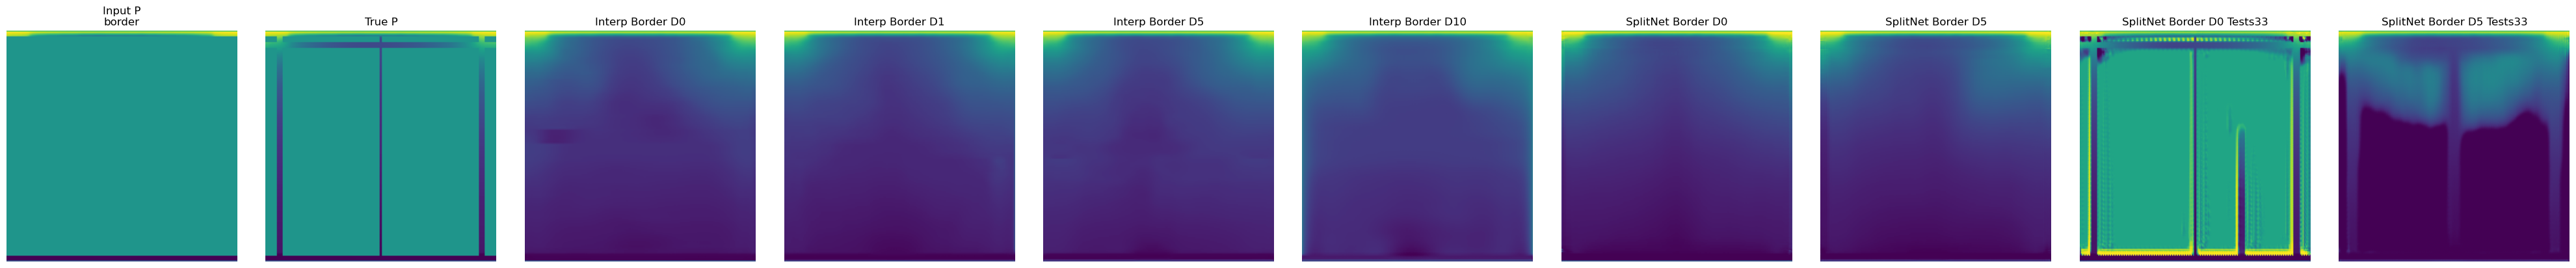

In [64]:
plot_model_comparison(
    sim_id=SIM,
    step=STEP,
    channel=1,   # pressure
)

C:\Users\jaden\AppData\Local\Temp\ipykernel_144788\1831322668.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


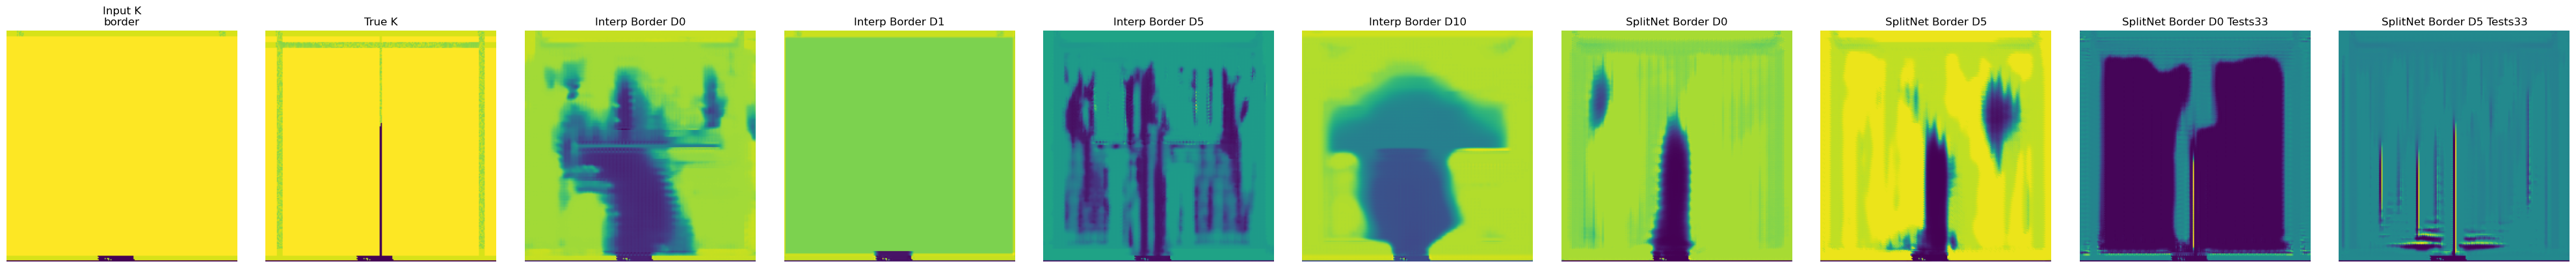

In [65]:
plot_model_comparison(
    sim_id=SIM,
    step=STEP,
    channel=0,   # conductivity
)